In [22]:
##### Creates maps of sub-national capital and labor data

import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

In [23]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# Import data
labor = gpd.read_file(f"{cd}/Data/Clean/Labor/subnational_labor_final_geo.shp")
capital = gpd.read_file(f"{cd}/Data/Clean/Capital_stock/subnational_capital_stock_final_GEO.shp")

# Import country boundaries 
countries = gpd.read_file("/Users/carinamanitius/Documents/Data/Admin_Boundaries/simple_for_map/World_Countries_Generalized.shp")

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures"

In [24]:
### Data prep

# align crs

crs = "ESRI:54042"

countries = countries.to_crs(crs)
capital = capital.to_crs(crs)
labor = labor.to_crs(crs)

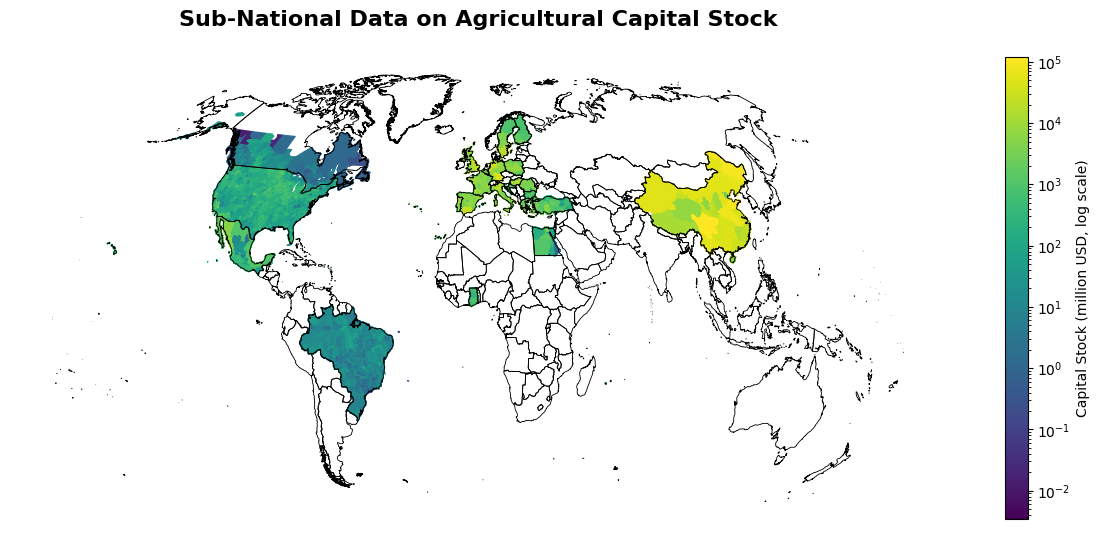

In [35]:
##### Plot sub-national data 

# Remove zero's
capital_positive = capital[capital['value'] > 0].copy()

### Plot
fig, ax = plt.subplots(figsize=(12,8))

# Plot positive values
capital_positive.plot(
    column='value',
    cmap='viridis',
    norm=LogNorm(),   
    edgecolor='face',
    ax=ax,
    legend=True,
    legend_kwds={
        'label': "Capital Stock (million USD, log scale)",
        'shrink': 0.6,
        'orientation': 'vertical'
    },
    zorder=2
)

# Add country boundaries
countries.boundary.plot(
    ax=ax,
    color='black',
    linewidth=0.6,
    zorder=10
)

# Aesthetics
ax.set_axis_off()  
ax.set_title("Sub-National Data on Agricultural Capital Stock", fontsize=16, weight='bold', pad=20)
plt.tight_layout()

plt.show()

fig.savefig(f"{fd}/subnational_capital_stock.png", dpi=300, bbox_inches='tight')

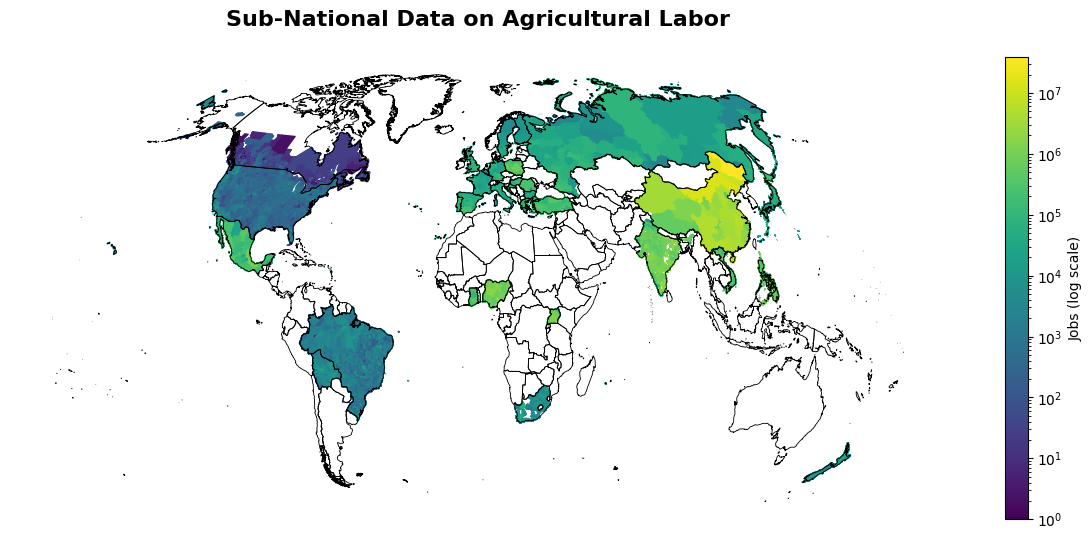

In [37]:
##### Plot sub-national data 

# Remove zero's
labor_positive = labor[labor['value'] > 0].copy()

### Plot
fig, ax = plt.subplots(figsize=(12,8))

# Plot positive values
labor_positive.plot(
    column='value',
    cmap='viridis',
    norm=LogNorm(),   
    edgecolor='face',
    ax=ax,
    legend=True,
    legend_kwds={
        'label': "Jobs (log scale)",
        'shrink': 0.6,
        'orientation': 'vertical'
    },
    zorder=2
)

# Add country boundaries
countries.boundary.plot(
    ax=ax,
    color='black',
    linewidth=0.6,
    zorder=10
)

# Aesthetics
ax.set_axis_off()  
ax.set_title("Sub-National Data on Agricultural Labor", fontsize=16, weight='bold', pad=20)
plt.tight_layout()

plt.show()

fig.savefig(f"{fd}/subnational_labor.png", dpi=300, bbox_inches='tight')

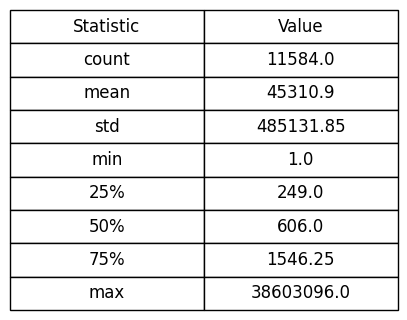

In [43]:
### Get basic stats 

stats = labor_positive['value'].describe().round(2)  

stats_df = pd.DataFrame(stats).reset_index()
stats_df.columns = ['Statistic', 'Value']

### Create fig of table
fig, ax = plt.subplots(figsize=(5, 2))  

ax.axis('off')

# Create table
table = ax.table(
    cellText=stats_df.values,
    colLabels=stats_df.columns,
    cellLoc='center',
    loc='center'
)

# Styling 
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)  

plt.show()

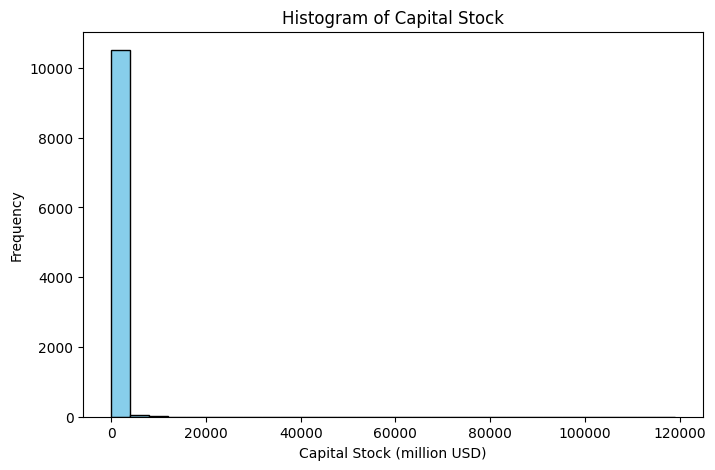

In [38]:
### Generate histograms

plt.figure(figsize=(8,5))
plt.hist(capital_positive['value'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Capital Stock (million USD)')
plt.ylabel('Frequency')
plt.title('Histogram of Capital Stock')
plt.show()

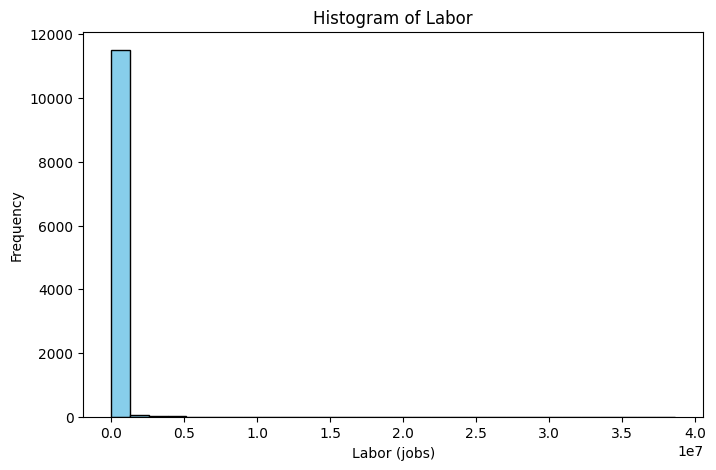

In [44]:
### Generate histograms

plt.figure(figsize=(8,5))
plt.hist(labor_positive['value'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Labor (jobs)')
plt.ylabel('Frequency')
plt.title('Histogram of Labor')
plt.show()